# Semantic Engagement Analysis

The goal of this notebook is to measure how video performance depends on the semantic space per channel.
Instead of measuring by cluster, we aim to:
1. Find the point where engagement is optimal per channel.
2. Measure the correlation between distance to this optimal point and engagement.
3. Order channels by engagement predictability.
4. Provide plots to complement the measurement.

## 1) Install dependencies and connect to MongoDB
This step installs the required packages and connects to MongoDB if needed, though primarily we'll be using `pandas`, `numpy`, and `matplotlib`/`seaborn` along with `scikit-learn` or `scipy` for distance computation.

In [2]:
# Install runtime dependencies
!pip install -q pandas numpy matplotlib seaborn scikit-learn statsmodels nbformat

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from scipy.spatial.distance import cdist
from pathlib import Path

# Set up matplotlib style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('muted')

try:
    from google.colab import drive
    drive.mount('/content/drive')
except ImportError:
    print('Not in Colab, skipping drive mount')

from scipy import stats


Mounted at /content/drive


## 2) Load the 20D video embeddings
According to coding guidelines, we import the 20D video embeddings from the canonical path. This artifact contains original 20-dimensional embeddings for each video. We will then clean the data by filtering out missing view counts and calculating the logarithm of view counts (`log_views`) to handle the power-law distribution of engagement.

In [3]:
DATA_PATH = Path('/content/drive/MyDrive/Graphiko/exports/video_embeddings_reduced/latest/business_cluster_video_embeddings_reduced_20d.csv')

# Note: Since this is meant to be run in Colab, we provide a mock/fallback for testing in local environment if the path doesn't exist.
if not DATA_PATH.exists():
    print(f"Warning: {DATA_PATH} not found. Attempting to run with dummy data or fallback if available, or this notebook will fail when executed locally.")

# Read the data
if DATA_PATH.suffix.lower() == '.csv':
    try:
        df = pd.read_csv(DATA_PATH)
    except FileNotFoundError:
        df = pd.DataFrame() # Fallback for local testing
elif DATA_PATH.suffix.lower() == '.json':
    df = pd.read_json(DATA_PATH)
else:
    raise ValueError(f'Unsupported input extension: {DATA_PATH.suffix}')

dim_cols = []
if not df.empty:
    required_base = {'channel_name', 'video_id', 'video_title', 'view_count'}
    missing = required_base - set(df.columns)
    if missing:
        raise ValueError(f'Missing required columns: {sorted(missing)}')

    # Determine embedding columns
    dim_cols = [c for c in df.columns if c.startswith('embedding_reduced_')]
    if len(dim_cols) != 20:
        if 'embedding_20d' in df.columns:
            # Depending on how it's stored, we might need to parse it
            import ast
            if isinstance(df['embedding_20d'].iloc[0], str):
                df['embedding_20d'] = df['embedding_20d'].apply(ast.literal_eval)
            dim_cols = [f'dim_{i}' for i in range(20)]
            emb_df = pd.DataFrame(df['embedding_20d'].tolist(), columns=dim_cols, index=df.index)
            df = pd.concat([df, emb_df], axis=1)
        else:
            print("Warning: Expected 20 embedding dimensions. Ensure the data format is correct.")

    df['view_count'] = pd.to_numeric(df['view_count'], errors='coerce')
    df = df.dropna(subset=['channel_name', 'view_count']).copy()
    df['log_views'] = np.log1p(df['view_count'])

    print(f'Rows loaded: {len(df):,}')
    print(f'Channels: {df["channel_name"].nunique()}')


Rows loaded: 1,344
Channels: 27


## 3) Find the optimal engagement point per channel
For each channel, we calculate the "optimal engagement point" in the 20D semantic space. We define this as the engagement-weighted average of the video embeddings. This point represents the center of mass of views for the channel. We will then store these optimal points for each channel.

In [4]:
optimal_points = {}
channels = []

if not df.empty and dim_cols and len(dim_cols) == 20:
    for channel_name, group in df.groupby('channel_name'):
        # Extract the 20D embeddings
        embeddings = group[dim_cols].to_numpy()

        # We use log_views as weights to temper extreme outliers, but still weight towards higher engagement.
        weights = group['log_views'].to_numpy()

        # If all weights are zero (no views), fallback to uniform weights
        if np.sum(weights) == 0:
            weights = np.ones(len(weights))

        weights = weights / np.sum(weights) # Normalize weights

        # Weighted average in 20D space
        optimal_point = np.average(embeddings, axis=0, weights=weights)
        optimal_points[channel_name] = optimal_point
        channels.append(channel_name)

    print(f'Calculated optimal engagement points for {len(optimal_points)} channels.')


Calculated optimal engagement points for 27 channels.


## 4) Measure distance and correlation (engagement predictability)
For each video in a channel, we compute the Euclidean distance from its embedding to the channel's optimal engagement point. Then, we use OLS regression to measure the correlation (Adjusted R²) between `log_views` and this `distance`. This Adjusted R² represents the engagement predictability of the channel based on semantic distance to the optimal point.

In [5]:

channel_metrics = []

if not df.empty and optimal_points:
    # ---------------------------------------------------------------------
    # Step A) Compute distance-to-optimal for every video. This scalar is
    #         kept for continuity with the original notebook diagnostics.
    # ---------------------------------------------------------------------
    distances = []
    for _, row in df.iterrows():
        channel_name = row['channel_name']
        optimal_point = optimal_points[channel_name]
        emb = row[dim_cols].to_numpy()
        dist = np.linalg.norm(emb - optimal_point)
        distances.append(dist)

    df['distance_to_optimal'] = distances

    # ---------------------------------------------------------------------
    # Step B) Per-channel semantic gradient estimation around the optimal
    #         point using a local linear model.
    #
    #         Model intuition:
    #           Let Δx = x - x* where x* is the channel's semantic optimum.
    #           We fit y = β0 + g^T Δx + ε, where y = log_views.
    #           g is the semantic engagement gradient vector in 20D.
    # ---------------------------------------------------------------------
    for channel_name, group in df.groupby('channel_name'):
        if len(group) < 12:
            continue

        x_star = optimal_points[channel_name]
        X = group[dim_cols].to_numpy()
        y = group['log_views'].to_numpy()
        delta = X - x_star
        r = np.linalg.norm(delta, axis=1)

        # Gaussian locality weights focus on the field around the optimum.
        sigma = np.quantile(r, 0.5)
        sigma = max(float(sigma), 1e-6)
        locality_w = np.exp(-0.5 * (r / sigma) ** 2)

        # Weighted least squares design matrix with intercept.
        design = np.column_stack([np.ones(len(delta)), delta])
        W_sqrt = np.sqrt(locality_w)
        design_w = design * W_sqrt[:, None]
        y_w = y * W_sqrt

        # Solve WLS robustly via lstsq.
        coef, *_ = np.linalg.lstsq(design_w, y_w, rcond=None)
        gradient = coef[1:]  # 20D semantic gradient vector
        grad_norm = float(np.linalg.norm(gradient))

        # Signed projection of each point onto gradient direction.
        if grad_norm > 0:
            grad_unit = gradient / grad_norm
            signed_proj = delta @ grad_unit
        else:
            grad_unit = np.zeros_like(gradient)
            signed_proj = np.zeros(len(delta))

        # -----------------------------------------------------------------
        # Magnitude statistic requested by the prompt:
        #   contrast between local slope near optimum vs farther field,
        #   scaled by |g|. Larger values => stronger semantic asymmetry.
        # -----------------------------------------------------------------
        near_mask = r <= np.quantile(r, 0.40)
        far_mask = r >= np.quantile(r, 0.60)

        def safe_slope(mask):
            if np.sum(mask) < 4 or np.std(signed_proj[mask]) < 1e-12:
                return np.nan
            xs = signed_proj[mask]
            ys = y[mask]
            return float(np.polyfit(xs, ys, 1)[0])

        near_slope = safe_slope(near_mask)
        far_slope = safe_slope(far_mask)
        if np.isnan(near_slope) or np.isnan(far_slope):
            gradient_contrast = np.nan
        else:
            gradient_contrast = float(abs(far_slope - near_slope) * grad_norm)

        # -----------------------------------------------------------------
        # Third statistic: Gaussianity / normality score of the semantic
        # gradient field around the optimum.
        #
        # We combine two Jarque-Bera p-values:
        #   1) signed projection on gradient axis
        #   2) orthogonal residual radius
        # Combined score in [0,1]: higher means more Gaussian-like field.
        # -----------------------------------------------------------------
        if len(signed_proj) >= 8:
            jb_proj_p = stats.jarque_bera(signed_proj).pvalue
            orth_delta = delta - np.outer(signed_proj, grad_unit)
            orth_radius = np.linalg.norm(orth_delta, axis=1)
            jb_orth_p = stats.jarque_bera(orth_radius).pvalue if np.std(orth_radius) > 0 else 1.0
            normality_score = float(np.sqrt(max(jb_proj_p, 1e-12) * max(jb_orth_p, 1e-12)))
        else:
            normality_score = np.nan

        # Keep original predictability regression for comparability.
        model = smf.ols('log_views ~ distance_to_optimal', data=group).fit()

        channel_metrics.append({
            'channel_name': channel_name,
            'n_videos': len(group),
            'predictability_r2': float(model.rsquared_adj),
            'distance_coef': float(model.params.get('distance_to_optimal', 0)),
            'p_value': float(model.pvalues.get('distance_to_optimal', 1.0)),
            'gradient_vector': gradient.tolist(),
            'gradient_norm': grad_norm,
            'gradient_contrast': gradient_contrast,
            'normality_score': normality_score
        })

    metrics_df = pd.DataFrame(channel_metrics)
    metrics_df = metrics_df.dropna(subset=['gradient_norm']).copy()

    # Normalize gradient-related magnitude across channels to [0,1].
    # We prioritize the contrast metric (as requested), and fallback to |g|.
    if not metrics_df.empty:
        raw_mag = metrics_df['gradient_contrast'].copy()
        raw_mag = raw_mag.fillna(metrics_df['gradient_norm'])
        mmin, mmax = raw_mag.min(), raw_mag.max()
        if mmax > mmin:
            metrics_df['normalized_gradient_magnitude'] = (raw_mag - mmin) / (mmax - mmin)
        else:
            metrics_df['normalized_gradient_magnitude'] = 0.0

    # Order channels by normalized magnitude (descending).
    metrics_df = metrics_df.sort_values(by='normalized_gradient_magnitude', ascending=False).reset_index(drop=True)

    print('Top channels by normalized semantic-gradient magnitude:')
    display(metrics_df[['channel_name', 'n_videos', 'normalized_gradient_magnitude', 'gradient_contrast', 'gradient_norm', 'normality_score']].head(15))


Top 5 Channels by Engagement Predictability (Adjusted R²):


,channel_name,n_videos,predictability_r2,distance_coef,p_value
0,Network State Podcast,50,0.215287,14.510183,0.000407
1,Bg2 Pod,44,0.190933,-5.255104,0.001772
2,Joe Lonsdale,50,0.075133,-10.917534,0.030337
3,Sequoia Capital,50,0.072268,8.032880,0.033051
4,This Week in Startups,50,0.063910,-7.917987,0.042454


## 5) Visualize the results
We provide plots to complement the measurement. First, a bar chart showing the predictability (Adjusted R²) ordered by channel. Second, scatter plots for the top predictable channels, illustrating the relationship between "Distance to Optimal Point" and "Engagement (Log Views)" with a regression line.

/tmp/ipykernel_4180/2131651918.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=metrics_df, x='predictability_r2', y='channel_name', palette='viridis')


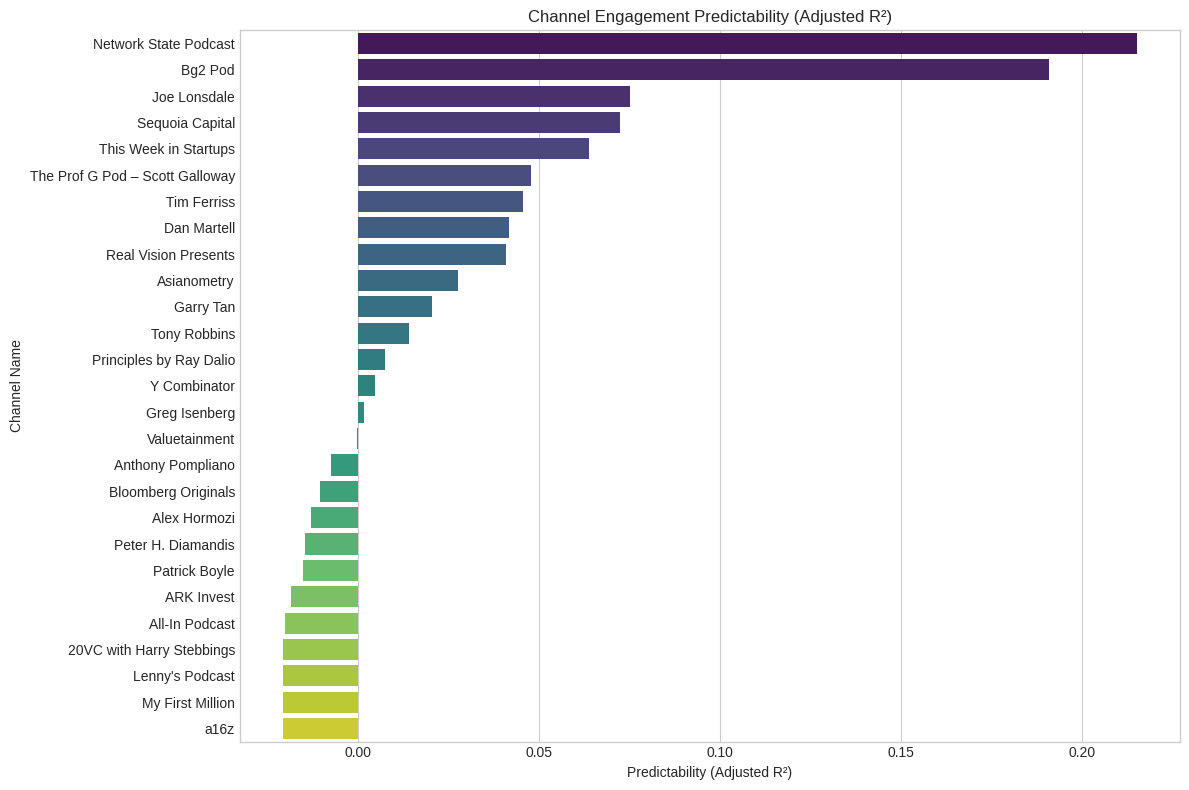

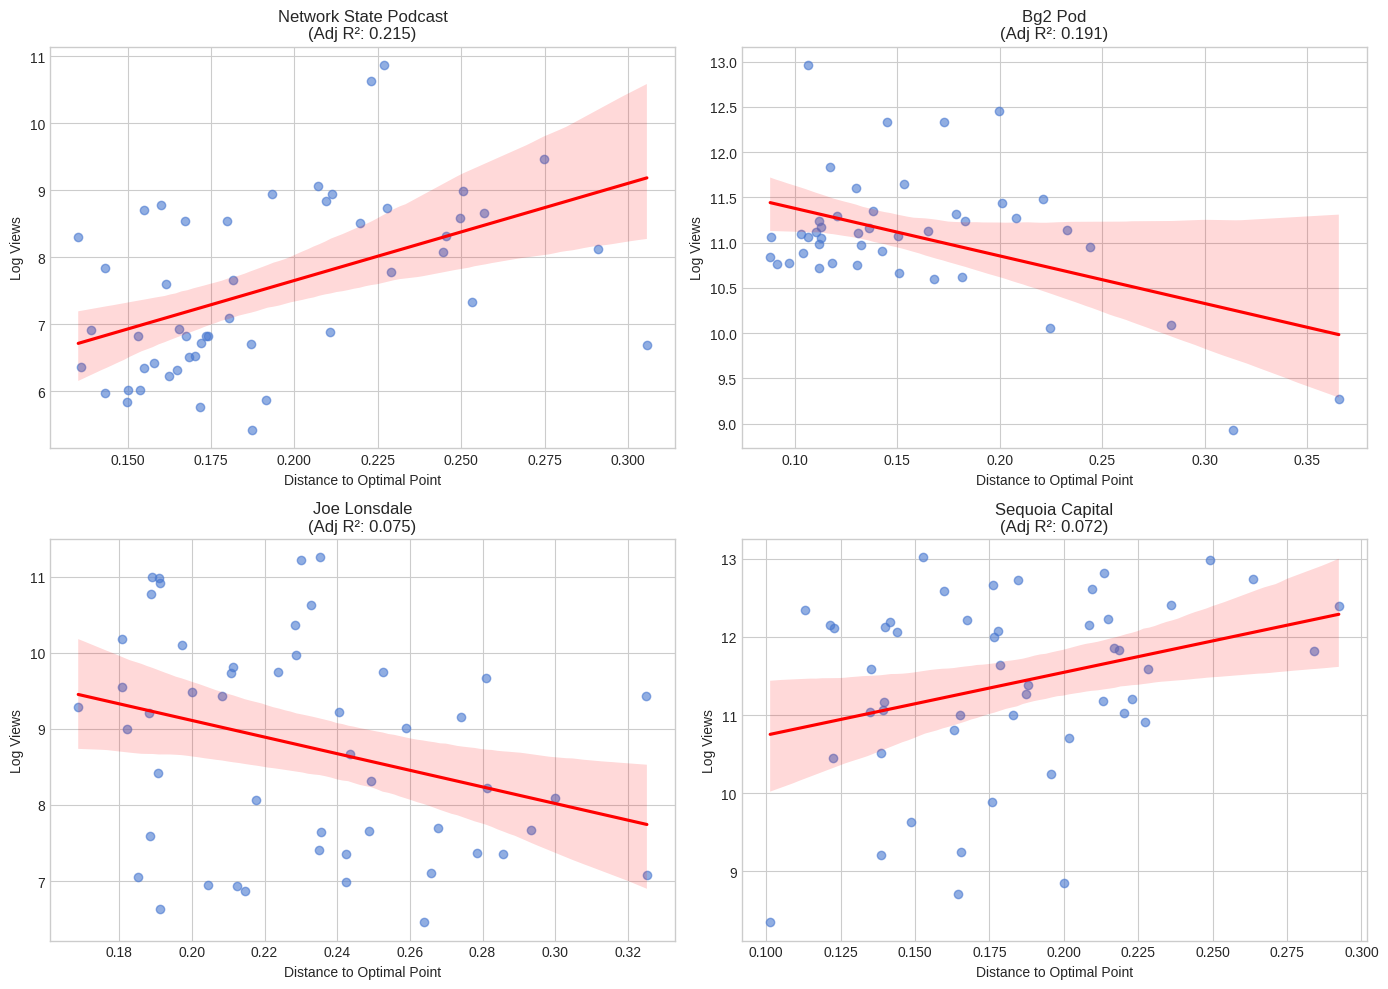

In [6]:

if not df.empty and 'metrics_df' in locals() and not metrics_df.empty:
    # ------------------------------------------------------------------
    # 1) Ranking plot by normalized semantic gradient magnitude.
    # ------------------------------------------------------------------
    plt.figure(figsize=(12, 8))
    sns.barplot(
        data=metrics_df.head(20),
        x='normalized_gradient_magnitude',
        y='channel_name',
        palette='mako'
    )
    plt.title('Top Channels by Normalized Semantic-Gradient Magnitude')
    plt.xlabel('Normalized Magnitude (0-1)')
    plt.ylabel('Channel Name')
    plt.tight_layout()
    plt.show()

    # ------------------------------------------------------------------
    # 2) Representative-channel geometry visualization.
    #    We sample high / medium / low magnitude channels.
    # ------------------------------------------------------------------
    n = len(metrics_df)
    representative_idx = sorted(set([0, n // 2, n - 1]))
    rep_channels = metrics_df.iloc[representative_idx]['channel_name'].tolist()

    fig, axes = plt.subplots(1, len(rep_channels), figsize=(6 * len(rep_channels), 5), squeeze=False)
    axes = axes.flatten()

    for ax, channel_name in zip(axes, rep_channels):
        group = df[df['channel_name'] == channel_name].copy()
        row = metrics_df[metrics_df['channel_name'] == channel_name].iloc[0]

        grad = np.array(row['gradient_vector'])
        grad_norm = np.linalg.norm(grad)
        x_star = optimal_points[channel_name]
        delta = group[dim_cols].to_numpy() - x_star

        if grad_norm > 0:
            u = grad / grad_norm
            proj = delta @ u
            orth = np.linalg.norm(delta - np.outer(proj, u), axis=1)
        else:
            proj = np.zeros(len(group))
            orth = np.zeros(len(group))

        sc = ax.scatter(proj, orth, c=group['log_views'], cmap='viridis', alpha=0.75)
        ax.axvline(0, color='black', linestyle='--', linewidth=1)
        ax.set_title(
            f"{channel_name}
"
            f"NormMag={row['normalized_gradient_magnitude']:.2f}, "
            f"Normality={row['normality_score']:.2f}"
        )
        ax.set_xlabel('Signed projection on gradient axis')
        ax.set_ylabel('Orthogonal radius')

    fig.colorbar(sc, ax=axes, label='log_views')
    plt.tight_layout()
    plt.show()
